# HW1, задача 1: аналитика и сравнение численных методов

Система: одна материальная точка массы $m$ соединена двумя пружинами с неподвижными точками крепления: одна точка лежит на наклонной стенке, другая на полу. Угол между полом и наклонной стенкой задан как

$$
\mu = 110^\circ.
$$

Координаты: $x$ направлена вправо, $y$ направлена вверх. Гравитация включена в формулы, но её можно отключить, положив `g = 0` в параметрах.

In [1]:
import math
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

from IPython.display import Markdown, display
from scipy.optimize import root

sp.init_printing(use_latex="mathjax")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.35
plt.rcParams["grid.linestyle"] = "--"

MU_DEG = 110.0
MU = math.radians(MU_DEG)
print(f"mu = {MU_DEG} degrees = {MU:.6f} rad")

mu = 110.0 degrees = 1.919862 rad


## Геометрия и энергия

Постановка: шарик в точке $(x,y)$ соединен с двумя неподвижными точками крепления.

Точка крепления на наклонной стенке:

$$
x_1=s_1\cos\mu, \qquad y_1=s_1\sin\mu.
$$

Точка крепления на полу:

$$
x_2=s_2, \qquad y_2=0.
$$

Текущие длины пружин:

$$
L_1=\sqrt{(x-x_1)^2+(y-y_1)^2}, \qquad
L_2=\sqrt{(x-x_2)^2+(y-y_2)^2}.
$$

Полная потенциальная энергия:

$$
V(x,y)=\frac{k_1}{2}(L_1-L_{10})^2+\frac{k_2}{2}(L_2-L_{20})^2+mgy.
$$

Силы выводятся через `sympy` как отрицательный градиент, но в удобной для чтения форме они выглядят так:

$$
\boxed{F_x=-k_1\left(1-\frac{L_{10}}{L_1}\right)(x-x_1)-k_2\left(1-\frac{L_{20}}{L_2}\right)(x-x_2)}
$$

$$
\boxed{F_y=-k_1\left(1-\frac{L_{10}}{L_1}\right)(y-y_1)-k_2\left(1-\frac{L_{20}}{L_2}\right)(y-y_2)-mg}
$$

In [2]:
x, y = sp.symbols("x y", real=True)
m, g = sp.symbols("m g", positive=True, real=True)
k1, k2 = sp.symbols("k_1 k_2", positive=True, real=True)
L10, L20 = sp.symbols("L_10 L_20", positive=True, real=True)
mu, s1, s2 = sp.symbols("mu s_1 s_2", positive=True, real=True)

q = sp.Matrix([x, y])
A = sp.Matrix([s1 * sp.cos(mu), s1 * sp.sin(mu)])
B = sp.Matrix([s2, 0])

r1 = sp.sqrt(((q - A).T * (q - A))[0])
r2 = sp.sqrt(((q - B).T * (q - B))[0])

U = sp.Rational(1, 2) * k1 * (r1 - L10) ** 2 + sp.Rational(1, 2) * k2 * (r2 - L20) ** 2 + m * g * y
F = -sp.Matrix([sp.diff(U, x), sp.diff(U, y)])
K = sp.hessian(U, (x, y))

print("Потенциальная энергия U(x, y):")
display(sp.Eq(sp.Symbol("U"), U))
print("\nСила F = -grad(U):")
display(sp.Eq(sp.MatrixSymbol("F", 2, 1), F))
print("\nМатрица жесткости K = Hessian(U):")
display(sp.Eq(sp.MatrixSymbol("K", 2, 2), K))

Потенциальная энергия U(x, y):


                                                                  2            ↪
               ⎛          _______________________________________⎞       ⎛     ↪
               ⎜         ╱                 2                   2 ⎟       ⎜     ↪
            k₁⋅⎝-L₁₀ + ╲╱  (-s₁⋅sin(μ) + y)  + (-s₁⋅cos(μ) + x)  ⎠    k₂⋅⎝-L₂₀ ↪
U = g⋅m⋅y + ─────────────────────────────────────────────────────── + ──────── ↪
                                       2                                       ↪

↪                         2
↪       _________________⎞ 
↪      ╱  2            2 ⎟ 
↪  + ╲╱  y  + (-s₂ + x)  ⎠ 
↪ ─────────────────────────
↪         2                


Сила F = -grad(U):


    ⎡     ⎛          _______________________________________⎞                  ↪
    ⎢     ⎜         ╱                 2                   2 ⎟                  ↪
    ⎢  k₁⋅⎝-L₁₀ + ╲╱  (-s₁⋅sin(μ) + y)  + (-s₁⋅cos(μ) + x)  ⎠⋅(-s₁⋅cos(μ) + x) ↪
    ⎢- ─────────────────────────────────────────────────────────────────────── ↪
    ⎢                   _______________________________________                ↪
    ⎢                  ╱                 2                   2                 ↪
    ⎢                ╲╱  (-s₁⋅sin(μ) + y)  + (-s₁⋅cos(μ) + x)                  ↪
F = ⎢                                                                          ↪
    ⎢           ⎛          _______________________________________⎞            ↪
    ⎢           ⎜         ╱                 2                   2 ⎟            ↪
    ⎢        k₁⋅⎝-L₁₀ + ╲╱  (-s₁⋅sin(μ) + y)  + (-s₁⋅cos(μ) + x)  ⎠⋅(-s₁⋅sin(μ ↪
    ⎢ -g⋅m - ───────────────────────────────────────────────────────────────── ↪
    ⎢                       


Матрица жесткости K = Hessian(U):


    ⎡   ⎛          _______________________________________⎞                    ↪
    ⎢   ⎜         ╱                 2                   2 ⎟                    ↪
    ⎢k₁⋅⎝-L₁₀ + ╲╱  (-s₁⋅sin(μ) + y)  + (-s₁⋅cos(μ) + x)  ⎠⋅(-s₁⋅cos(μ) + x)⋅( ↪
    ⎢───────────────────────────────────────────────────────────────────────── ↪
    ⎢                                                             3/2          ↪
    ⎢                      ⎛                2                   2⎞             ↪
    ⎢                      ⎝(-s₁⋅sin(μ) + y)  + (-s₁⋅cos(μ) + x) ⎠             ↪
K = ⎢                                                                          ↪
    ⎢                                                    ⎛          __________ ↪
    ⎢                                                    ⎜         ╱           ↪
    ⎢                                                 k₁⋅⎝-L₁₀ + ╲╱  (-s₁⋅sin( ↪
    ⎢                                                 ──────────────────────── ↪
    ⎢                       

## Равновесие и линеаризация

Положение равновесия $q_0=(x_0,y_0)^T$ находится из системы

$$
F(q_0)=0.
$$

Из-за корней в $r_1$ и $r_2$ это нелинейная система. Поэтому равновесие ищется численно, но сами уравнения и производные строятся символически.

Для малых отклонений $\eta=q-q_0$:

$$
U(q_0+\eta)\approx U(q_0)+\frac12\eta^T K(q_0)\eta,
$$

и уравнение движения принимает вид

$$
m\ddot{\eta}+K(q_0)\eta=0.
$$

Это уже линейная система с постоянными коэффициентами, её решение удобно записать через нормальные моды.

In [3]:

params = {
    m: 1.0,
    g: 9.81,
    k1: 35.0,
    k2: 35.0,
    L10: 0.55,
    L20: 0.65,
    mu: MU,
    s1: 1.20,
    s2: 1.35,
}

F_num = sp.lambdify((x, y), F.subs(params), "numpy")
U_num = sp.lambdify((x, y), U.subs(params), "numpy")
K_num_expr = K.subs(params)
K_num_fun = sp.lambdify((x, y), K_num_expr, "numpy")

A_num = np.array([params[s1] * math.cos(MU), params[s1] * math.sin(MU)], dtype=float)
B_num = np.array([params[s2], 0.0], dtype=float)

def force_np(pos):
    return np.asarray(F_num(float(pos[0]), float(pos[1])), dtype=float).reshape(2)

# Несколько стартовых приближений делают поиск устойчивее при изменении параметров.
guesses = [
    np.array([0.20, 0.20]),
    np.array([0.40, 0.20]),
    np.array([0.40, 0.45]),
    np.array([0.70, 0.25]),
    0.5 * (A_num + B_num),
]

solution = None
for guess in guesses:
    candidate = root(force_np, guess)
    if candidate.success and np.linalg.norm(force_np(candidate.x)) < 1e-7:
        solution = candidate
        break

if solution is None:
    raise RuntimeError("Не удалось найти равновесие. Попробуйте другие параметры или начальные приближения.")

q_eq = solution.x.astype(float)
K_eq = np.array(K_num_fun(q_eq[0], q_eq[1]), dtype=float)
MASS = float(params[m])

print("Точка крепления A на наклонной стенке:", A_num)
print("Точка крепления B на полу:", B_num)
print("Положение равновесия q0 =", q_eq)
print("Проверка |F(q0)| =", np.linalg.norm(force_np(q_eq)))
print("\nK(q0) =")
print(K_eq)
print("\nСобственные значения K/m =", np.linalg.eigvalsh(K_eq / MASS))

display(Markdown("Линеаризованные уравнения:"))
display(sp.Eq(sp.MatrixSymbol("eta''", 2, 1), -sp.Matrix(K_eq / MASS) * sp.MatrixSymbol("eta", 2, 1)))

Точка крепления A на наклонной стенке: [-0.41042417  1.12763114]
Точка крепления B на полу: [1.35 0.  ]
Положение равновесия q0 = [0.34954881 0.32399862]
Проверка |F(q0)| = 3.972054645195637e-15

K(q0) =
[[ 58.75885463 -15.02947635]
 [-15.02947635  42.20358301]]

Собственные значения K/m = [33.32300172 67.63943591]


Линеаризованные уравнения:

        ⎡-58.7588546264018  15.0294763457464 ⎤  
eta'' = ⎢                                    ⎥⋅η
        ⎣15.0294763457464   -42.2035830061199⎦  

## Аналитическое решение линеаризованной системы

Так как $K(q_0)$ симметрична, решаем задачу на собственные значения:

$$
\frac{K(q_0)}{m}P=P\Omega^2.
$$

Если $\eta(0)=\eta_0$, $\dot\eta(0)=v_0$, то в базисе нормальных мод:

$$
\eta(t)=P\left[\cos(\Omega t)c+\Omega^{-1}\sin(\Omega t)d\right],
$$

где

$$
c=P^T\eta_0, \qquad d=P^Tv_0.
$$

Положение точки в исходных координатах:

$$
q(t)=q_0+\eta(t).
$$

Нормальные частоты omega = [5.77260788 8.22431978]


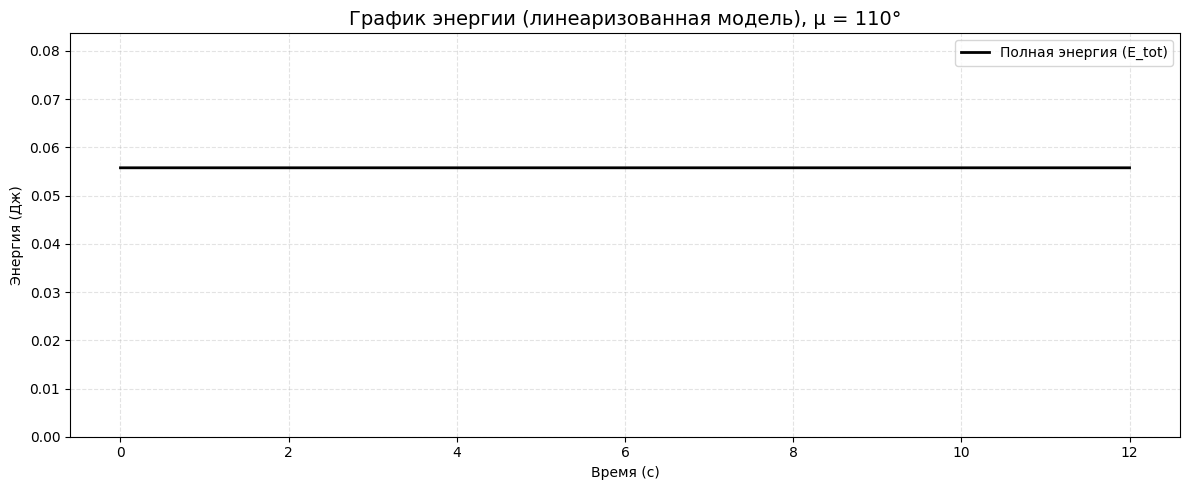

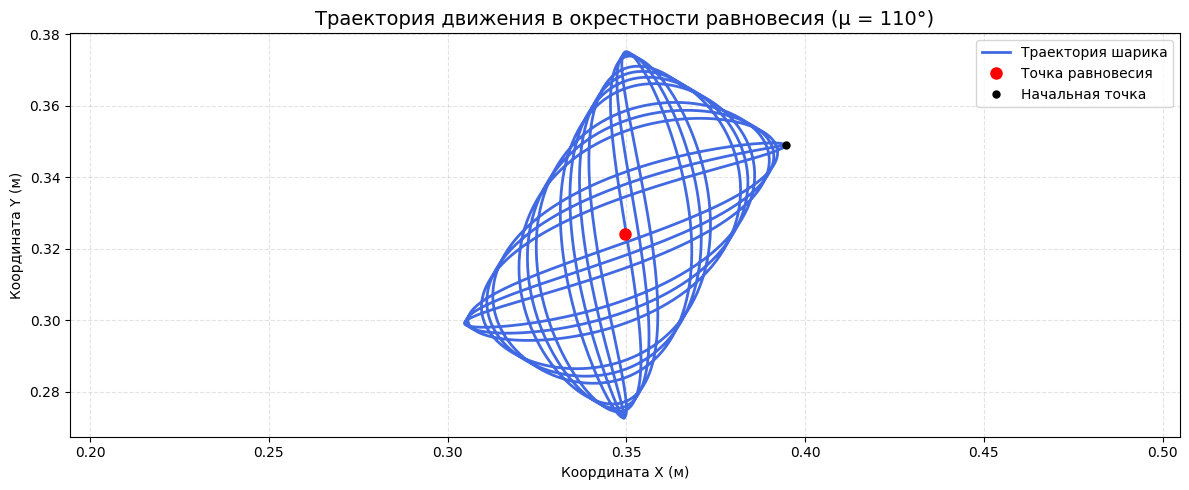

In [4]:
def linear_analytic_solution(ts, q0, v0, q_eq, K_eq, mass):
    """Analytic solution of m*eta'' + K*eta = 0."""
    eigvals, P = np.linalg.eigh(K_eq / mass)
    if np.any(eigvals <= 0):
        raise RuntimeError("Равновесие неустойчиво: есть неположительные собственные значения K/m.")

    omega = np.sqrt(eigvals)
    eta0 = q0 - q_eq
    c = P.T @ eta0
    d = P.T @ v0

    modes = np.cos(np.outer(ts, omega)) * c + np.sin(np.outer(ts, omega)) * (d / omega)
    eta = modes @ P.T

    mode_vel = -np.sin(np.outer(ts, omega)) * (omega * c) + np.cos(np.outer(ts, omega)) * d
    vel = mode_vel @ P.T
    pos = q_eq + eta
    return pos, vel, omega

# Малое начальное отклонение: здесь линеаризация должна хорошо совпадать с нелинейной моделью.
q0_linear = q_eq + np.array([0.045, 0.025])
v0_linear = np.array([0.0, 0.0])
ts = np.linspace(0.0, 12.0, 1600)

pos_lin, vel_lin, omega = linear_analytic_solution(ts, q0_linear, v0_linear, q_eq, K_eq, MASS)

# Энергия линеаризованной системы: T + 1/2 eta^T K eta.
eta = pos_lin - q_eq
E_lin = 0.5 * MASS * np.sum(vel_lin**2, axis=1) + 0.5 * np.einsum("ni,ij,nj->n", eta, K_eq, eta)

print("Нормальные частоты omega =", omega)

plt.figure(figsize=(12, 5))
plt.plot(ts, E_lin, color="black", lw=2, label="Полная энергия (E_tot)")
plt.title("График энергии (линеаризованная модель), μ = 110°", fontsize=14)
plt.xlabel("Время (с)")
plt.ylabel("Энергия (Дж)")
plt.ylim(0, float(np.max(E_lin)) * 1.5 + 1e-15)
plt.grid(True, linestyle="--")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(pos_lin[:, 0], pos_lin[:, 1], color="royalblue", lw=2, label="Траектория шарика")
plt.plot(q_eq[0], q_eq[1], "ro", markersize=8, label="Точка равновесия")
plt.plot(q0_linear[0], q0_linear[1], "ko", markersize=5, label="Начальная точка")
plt.title("Траектория движения в окрестности равновесия (μ = 110°)", fontsize=14)
plt.xlabel("Координата X (м)")
plt.ylabel("Координата Y (м)")
plt.axis("equal")
plt.grid(True, linestyle="--")
plt.legend()
plt.tight_layout()
plt.show()

## Численное решение исходной нелинейной системы

Дальше интегрируется уже исходная нелинейная система:

$$
\dot q = v, \qquad \dot v = \frac{F(q)}{m}.
$$

Сравниваются четыре метода:

- явный Эйлер;
- неявный Эйлер;
- полуявный, или симплектический, Эйлер;
- velocity Verlet.

Для неявного Эйлера на каждом шаге решается система

$$
q_{n+1}=q_n+h v_{n+1}, \qquad v_{n+1}=v_n+h a(q_{n+1}).
$$

In [5]:
def acceleration(q):
    return force_np(q) / MASS

def total_energy(q, v):
    kinetic = 0.5 * MASS * float(np.dot(v, v))
    potential = float(U_num(float(q[0]), float(q[1])))
    return kinetic + potential

def step_explicit_euler(q, v, h):
    a = acceleration(q)
    return q + h * v, v + h * a

def step_semi_implicit_euler(q, v, h):
    v_next = v + h * acceleration(q)
    q_next = q + h * v_next
    return q_next, v_next

def step_implicit_euler(q, v, h):
    def residual(z):
        q_next = z[:2]
        v_next = z[2:]
        return np.concatenate([
            q_next - q - h * v_next,
            v_next - v - h * acceleration(q_next),
        ])

    # Стартовое приближение берем из полуявного Эйлера.
    q_guess, v_guess = step_semi_implicit_euler(q, v, h)
    sol = root(residual, np.concatenate([q_guess, v_guess]), method="hybr")
    if not sol.success:
        raise RuntimeError("Неявный Эйлер: root solver не сошелся")
    return sol.x[:2], sol.x[2:]

def step_velocity_verlet(q, v, h):
    a0 = acceleration(q)
    q_next = q + h * v + 0.5 * h * h * a0
    a1 = acceleration(q_next)
    v_next = v + 0.5 * h * (a0 + a1)
    return q_next, v_next

METHODS = {
    "explicit": ("Явный Эйлер", step_explicit_euler),
    "implicit": ("Неявный Эйлер", step_implicit_euler),
    "semi": ("Полуявный Эйлер", step_semi_implicit_euler),
    "verlet": ("Верле", step_velocity_verlet),
}

def simulate_methods(q0, v0, h, T):
    steps = int(T / h) + 1
    time = np.linspace(0.0, h * (steps - 1), steps)
    results = {}

    for method_id, (label, stepper) in METHODS.items():
        q_hist = np.zeros((steps, 2))
        v_hist = np.zeros((steps, 2))
        e_hist = np.zeros(steps)
        q_hist[0] = q0
        v_hist[0] = v0
        e_hist[0] = total_energy(q0, v0)

        q_curr = q0.copy()
        v_curr = v0.copy()
        for i in range(1, steps):
            q_curr, v_curr = stepper(q_curr, v_curr, h)
            q_hist[i] = q_curr
            v_hist[i] = v_curr
            e_hist[i] = total_energy(q_curr, v_curr)

        results[method_id] = {
            "label": label,
            "q": q_hist,
            "v": v_hist,
            "E": e_hist,
        }

    return time, results

# Два режима: малое отклонение для проверки линеаризации и заметное отклонение для сравнения методов.
time_small, results_small = simulate_methods(q0_linear.copy(), v0_linear.copy(), h=0.005, T=12.0)
q0_methods = q_eq + np.array([0.18, 0.10])
v0_methods = np.array([0.15, -0.05])
time, results = simulate_methods(q0_methods, v0_methods, h=0.012, T=18.0)

print("Симуляции завершены")
for method_id, result in results.items():
    drift = result["E"][-1] - result["E"][0]
    rel = drift / max(abs(result["E"][0]), 1e-12)
    print(f"{result['label']:<18} ΔE = {drift:+.6e} J, relative = {rel:+.3%}")

Симуляции завершены
Явный Эйлер        ΔE = +3.144354e+05 J, relative = +2556628.660%
Неявный Эйлер      ΔE = -8.862930e-01 J, relative = -7.206%
Полуявный Эйлер    ΔE = -1.686873e-02 J, relative = -0.137%
Верле              ΔE = -2.503215e-05 J, relative = -0.000%


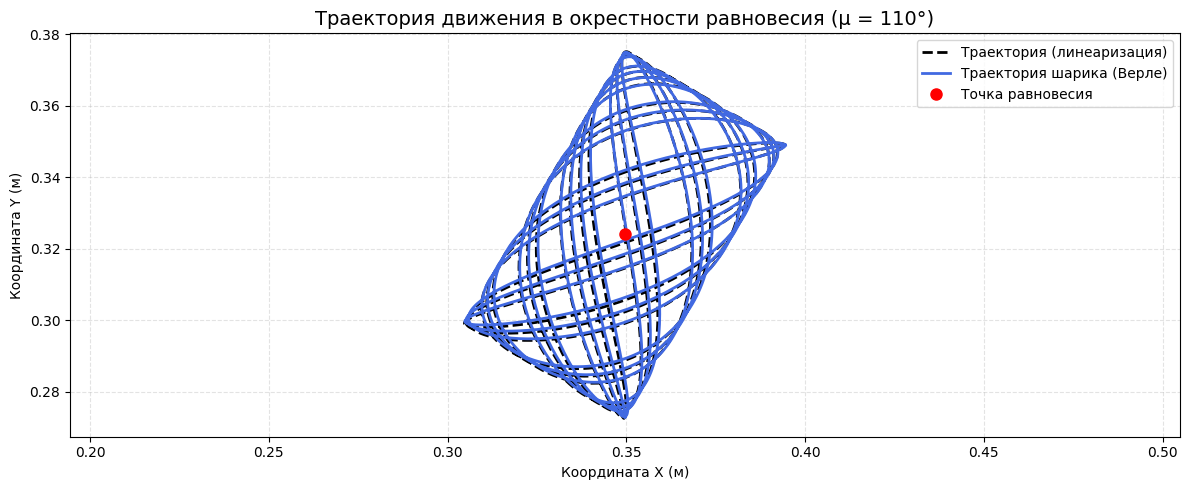

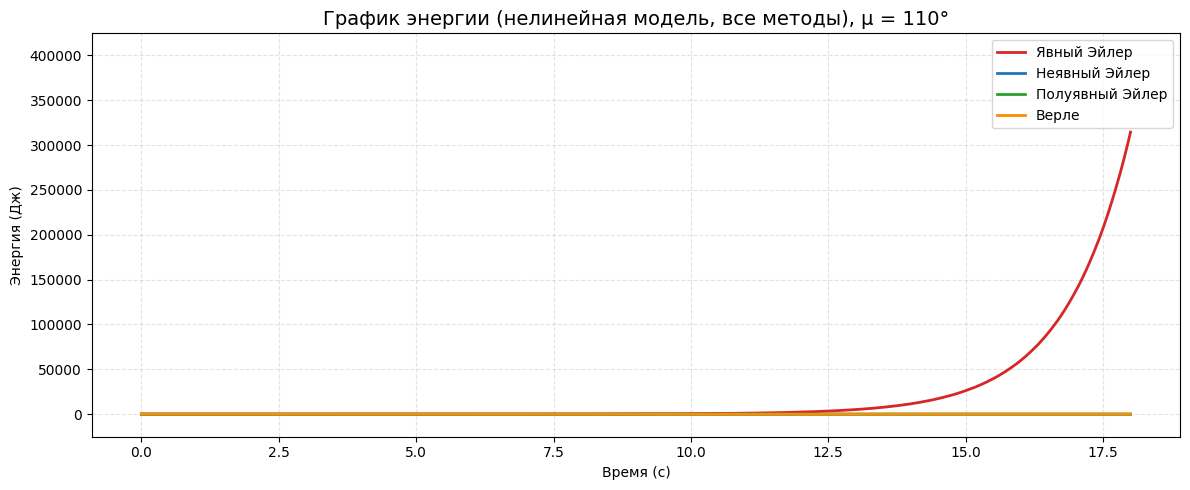

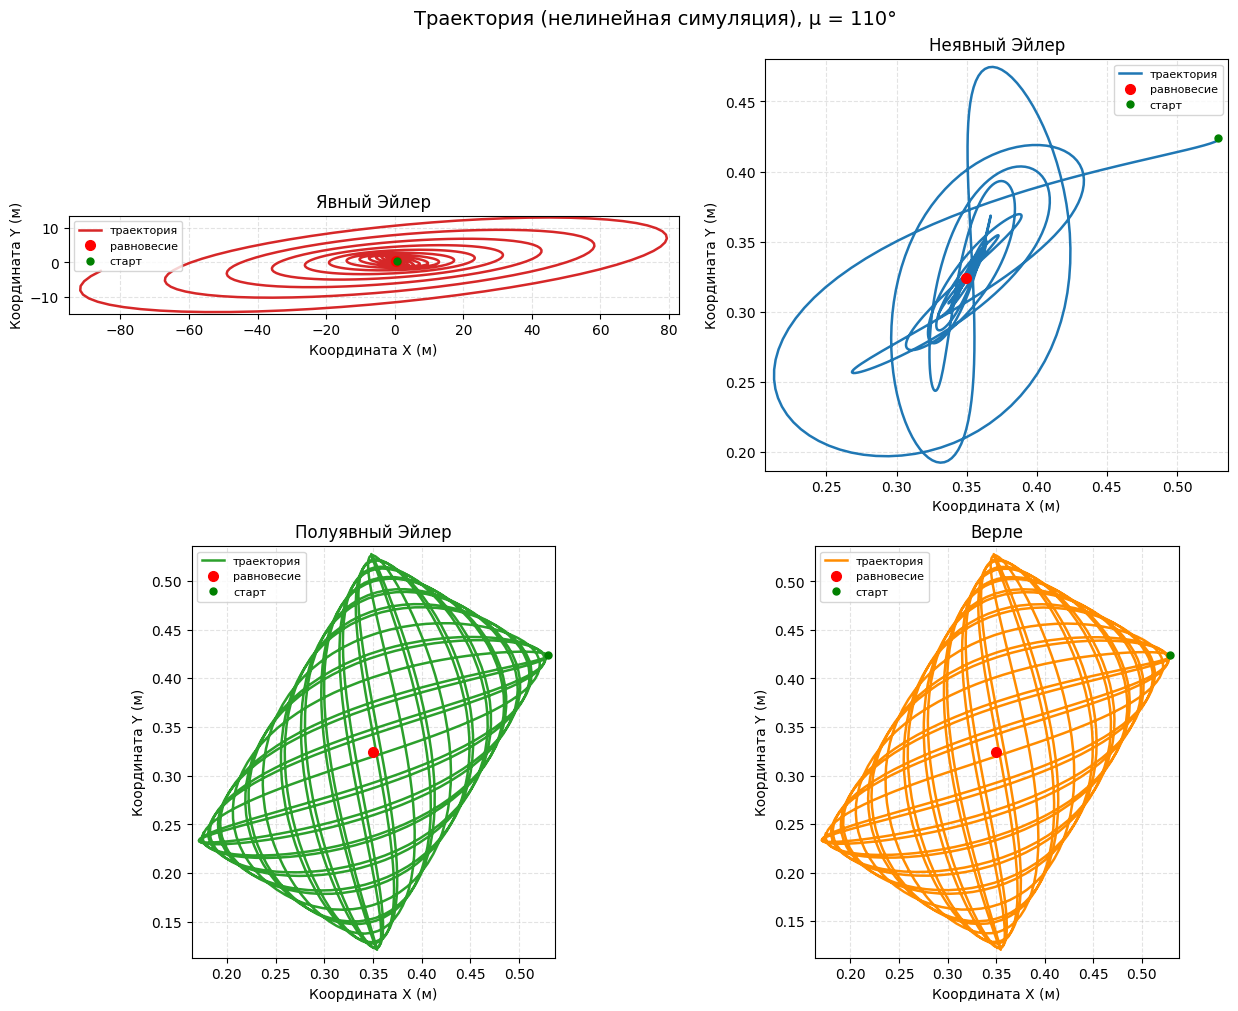

In [6]:
colors = {
    "explicit": "tab:red",
    "implicit": "tab:blue",
    "semi": "tab:green",
    "verlet": "darkorange",
}

# plt.figure(figsize=(12, 5)), lw=2, grid linestyle='--', title fontsize=14

verlet_small = results_small["verlet"]
E_vs = verlet_small["E"]


plt.figure(figsize=(12, 5))
plt.plot(pos_lin[:, 0], pos_lin[:, 1], color="black", lw=2, ls="--", label="Траектория (линеаризация)")
plt.plot(verlet_small["q"][:, 0], verlet_small["q"][:, 1], color="royalblue", lw=2, label="Траектория шарика (Верле)")
plt.plot(q_eq[0], q_eq[1], "ro", markersize=8, label="Точка равновесия")
plt.title("Траектория движения в окрестности равновесия (μ = 110°)", fontsize=14)
plt.xlabel("Координата X (м)")
plt.ylabel("Координата Y (м)")
plt.axis("equal")
plt.grid(True, linestyle="--")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
for method_id, result in results.items():
    plt.plot(time, result["E"], color=colors[method_id], lw=2, label=result["label"])
plt.title("График энергии (нелинейная модель, все методы), μ = 110°", fontsize=14)
plt.xlabel("Время (с)")
plt.ylabel("Энергия (Дж)")
vals = np.concatenate([r["E"] for r in results.values()])
vals = vals[np.isfinite(vals)]
e_min, e_max = float(np.min(vals)), float(np.max(vals))
span = max(e_max - e_min, 1e-12)
plt.ylim(e_min - 0.08 * span, e_max + 0.35 * span)
plt.grid(True, linestyle="--")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(13, 10), constrained_layout=True)
method_order = ("explicit", "implicit", "semi", "verlet")
for ax, method_id in zip(axes.ravel(), method_order):
    r = results[method_id]
    q = r["q"]
    ax.plot(q[:, 0], q[:, 1], color=colors[method_id], lw=1.8, label="траектория")
    ax.plot(q_eq[0], q_eq[1], "ro", markersize=7, label="равновесие")
    ax.plot(q0_methods[0], q0_methods[1], "go", markersize=5, label="старт")
    ax.set_title(r["label"], fontsize=12)
    ax.set_xlabel("Координата X (м)")
    ax.set_ylabel("Координата Y (м)")
    ax.grid(True, linestyle="--")
    ax.legend(loc="best", fontsize=8)

    xs = q[:, 0]
    ys = q[:, 1]
    ok = np.isfinite(xs) & np.isfinite(ys)
    xs = np.append(xs[ok], [float(q_eq[0]), float(q0_methods[0])])
    ys = np.append(ys[ok], [float(q_eq[1]), float(q0_methods[1])])
    xmin, xmax = float(np.min(xs)), float(np.max(xs))
    ymin, ymax = float(np.min(ys)), float(np.max(ys))
    sx = max(xmax - xmin, 1e-9)
    sy = max(ymax - ymin, 1e-9)
    px = max(0.02 * sx, 1e-6)
    py = max(0.02 * sy, 1e-6)
    ax.set_xlim(xmin - px, xmax + px)
    ax.set_ylim(ymin - py, ymax + py)
    ax.set_aspect("equal", adjustable="box")

fig.suptitle("Траектория (нелинейная симуляция), μ = 110°", fontsize=14)
plt.show()


## Выводы по графикам

**Линеаризация (первые два графика после аналитики).**  
График энергии для линеаризованной модели с аналитическим решением должен быть почти горизонтальным: при малых амплитудах полная энергия в квадратичном приближении сохраняется с точностью машинного шума. Траектория в плоскости $(x,y)$ — гладкая замкнутая кривая вокруг положения равновесия; это типичная картина двух связанных гармонических мод.

**Сравнение «линеаризация vs малая нелинейная симуляция (Верле)».**  
Если начальное отклонение мало, кривые энергии и траектории Верле и аналитики линеаризации близки: нелинейные члены малы, линеаризация описывает движение хорошо. Заметное расхождение сигнализирует, что амплитуда уже не «мала» и нужна полная нелинейная модель.

**Энергия, все четыре метода на нелинейной системе.**  
Ожидаемая картина: **явный Эйлер** часто даёт **рост** численной энергии (разгон), **неявный Эйлер** — **искусственное затухание** (энергия «течёт» вниз). **Полуявный (симплектический) Эйлер** и **Верле** обычно **заметно ближе к сохранению энергии** на тех же шаге и времени, так как ближе к гамильтоновой структуре задачи (хотя на нелинейной системе идеального сохранения нет из‑за дискретизации).

**Последний график траекторий (сабплоты $2\times 2$).**  
На каждом подграфике показана траектория **одного** численного метода, с **собственным** масштабом по осям (равновесие и старт включены в кадр). Так удобно сравнивать форму движения: у явного Эйлера при неустойчивости траектория «разъезжается» в своём окне, а у остальных методов обычно остаётся компактной около равновесия.

**Практический итог.**  
Для долгой симуляции консервативной механики предпочтительны **симплектический Эйлер** или **Верле**; шаг $\Delta t$ нужно подбирать так, чтобы и явный Эйлер не «взрывался», если он используется как эталон сравнения.
